This notebook is just for preprocessing data (cleaning, normalization and all)

In [1]:
# Load the raw data
import pandas as pd
import numpy as np

from pathlib import Path

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/raw/student_learning_data_raw.csv")

df.head()

,student_id,age,gender,department,semester,attendance_pct,assignment_avg,assignment_completion_pct,quiz_avg,quiz_attempts,study_hours_week,participation_score,lms_login_count,lms_active_days,resources_accessed,video_completion_pct,previous_gpa,previous_failures,late_assignments,discussion_participation,support_requested,midterm_score,final_score,performance_level,risk_level
0,STU100001,22,Male,ECE,5,66.1,74.9,44.8,60.1,12,15.5,68.3,23,18.0,33,62.9,6.77,0,4,9.0,Yes,57.1,58.5,Average,Medium
1,STU100002,18,Female,ECE,8,89.1,59.8,69.1,54.5,12,11.4,63.6,20,13.0,35,69.9,5.17,1,0,14.0,No,71.8,65.2,Good,Low
2,STU100003,23,Female,ECE,5,76.9,68.6,96.7,79.3,14,15.7,72.2,40,21.0,55,74.4,7.24,0,0,12.0,No,67.1,80.7,Excellent,Low
3,STU100004,22,Male,ECE,4,89.0,78.8,52.1,49.8,12,18.6,52.0,19,18.0,51,67.9,7.53,0,1,16.0,Yes,72.0,56.7,Average,Medium
4,STU100005,23,Female,MECH,4,62.0,47.7,47.7,35.3,10,7.6,59.9,23,2.0,1,71.3,4.29,3,3,6.0,Yes,46.1,40.4,Poor,High


Because our raw dataset contains the problems that preprocessing needs to solve:

Missing values
      +
Duplicate rows
      +
Categorical variables
      +
Different numerical scales

In [3]:
# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 20


In [4]:
df = df.drop_duplicates().reset_index(drop=True)


print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (8000, 25)


In [5]:
# Check missing values
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

attendance_pct          80
assignment_avg          80
quiz_avg                80
study_hours_week        80
participation_score     80
lms_active_days         80
video_completion_pct    80
previous_gpa            80
midterm_score           80
dtype: int64


In [ ]:
X = df.drop(                         # inp feature list
    columns = [
        'final_score',
        'performance_level',
        'risk_level'
    ]
)

y = df['risk_level']               # oup target feature list

In [9]:
# Check our feature/target shapes
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (8000, 22)
Target shape: (8000,)


In [11]:
# Identify numerical and categorical features
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['student_id', 'gender', 'department', 'support_requested']

Numerical features:
['age', 'semester', 'attendance_pct', 'assignment_avg', 'assignment_completion_pct', 'quiz_avg', 'quiz_attempts', 'study_hours_week', 'participation_score', 'lms_login_count', 'lms_active_days', 'resources_accessed', 'video_completion_pct', 'previous_gpa', 'previous_failures', 'late_assignments', 'discussion_participation', 'midterm_score']


C:\Users\navad\AppData\Local\Temp\ipykernel_3172\2734670694.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [20]:
# Handle missing numerical values
for column in numerical_features:
    df[column] = df[column].fillna(
        df[column].median()
    )

# once again check null values now 
df[numerical_features].isnull().sum()

age                          0
semester                     0
attendance_pct               0
assignment_avg               0
assignment_completion_pct    0
quiz_avg                     0
quiz_attempts                0
study_hours_week             0
participation_score          0
lms_login_count              0
lms_active_days              0
resources_accessed           0
video_completion_pct         0
previous_gpa                 0
previous_failures            0
late_assignments             0
discussion_participation     0
midterm_score                0
dtype: int64

In [21]:
# handle categorical missing values
df[categorical_features].isnull().sum()

student_id           0
gender               0
department           0
support_requested    0
dtype: int64

Check invalid ranges

In [22]:
# Check Attendance invalid ranges

print(
    "Invalid attendance:",
    ((df["attendance_pct"] < 0) |
     (df["attendance_pct"] > 100)).sum()
)

print(
    "Invalid assignment scores:",
    ((df["assignment_avg"] < 0) |
     (df["assignment_avg"] > 100)).sum()
)

print(
    "Invalid quiz scores:",
    ((df["quiz_avg"] < 0) |
     (df["quiz_avg"] > 100)).sum()
)

print(
    "Invalid final scores:",
    ((df["final_score"] < 0) |
     (df["final_score"] > 100)).sum()
)

Invalid attendance: 0
Invalid assignment scores: 0
Invalid quiz scores: 0
Invalid final scores: 0


In [23]:
clean_path = "../data/processed/student_data_clean.csv"

df.to_csv(
    clean_path,
    index=False
)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


EXPLORATORY DATA ANALYSIS

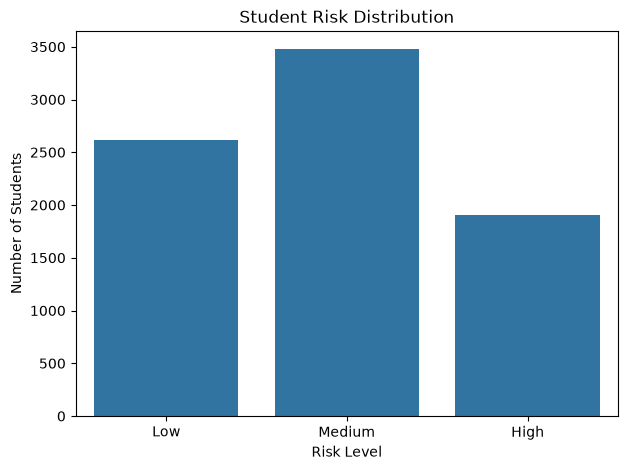

In [25]:
# EDA 1 — Risk distribution
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="risk_level",
    order=["Low", "Medium", "High"]
)

plt.title("Student Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Students")

plt.show()

In [ ]:
# EDA 2 — Risk percentages
risk_percentage = (
    df["risk_level"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

risk_percentage

# 43% of students are currently classified as medium risk

risk_level
Medium    43.44
Low       32.71
High      23.85
Name: proportion, dtype: float64

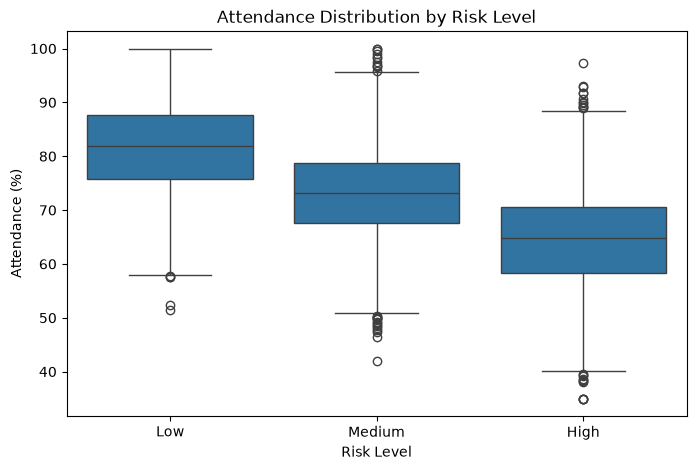

In [27]:
# EDA 3 — Risk vs Attendance
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="risk_level",
    y="attendance_pct",
    order=["Low", "Medium", "High"]
)

plt.title("Attendance Distribution by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Attendance (%)")

plt.show()

Low Risk
   ↑ attendance

Medium Risk
   ↓ attendance

High Risk
   ↓↓↓ attendance

---

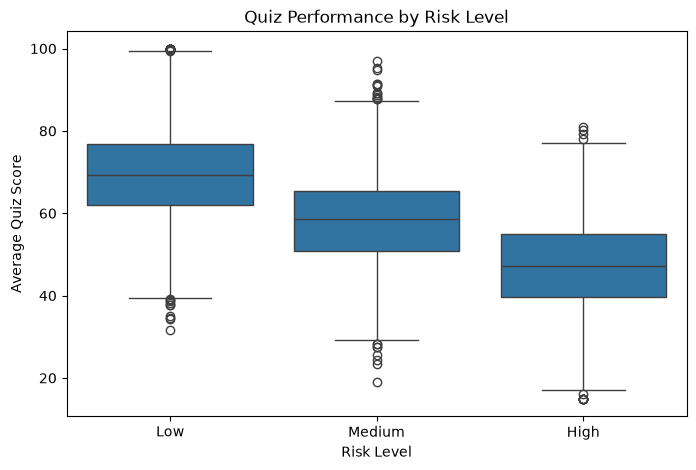

In [28]:
# EDA 4 — Risk vs Quiz Performance
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="risk_level",
    y="quiz_avg",
    order=["Low", "Medium", "High"]
)

plt.title("Quiz Performance by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Average Quiz Score")

plt.show()

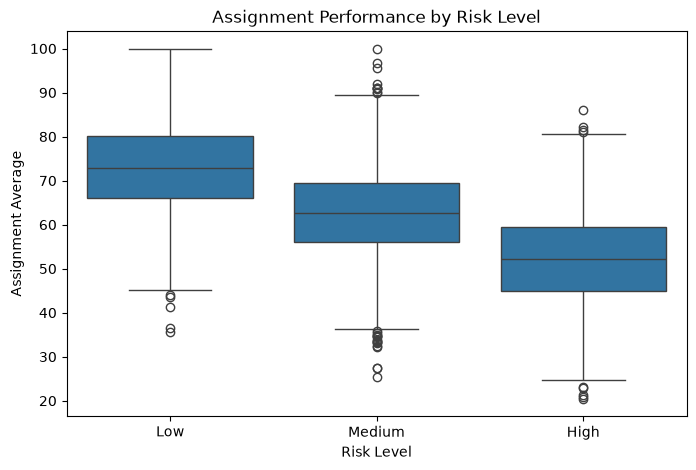

In [29]:
# EDA 5 — Risk vs Assignment Performance
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="risk_level",
    y="assignment_avg",
    order=["Low", "Medium", "High"]
)

plt.title("Assignment Performance by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Assignment Average")

plt.show()

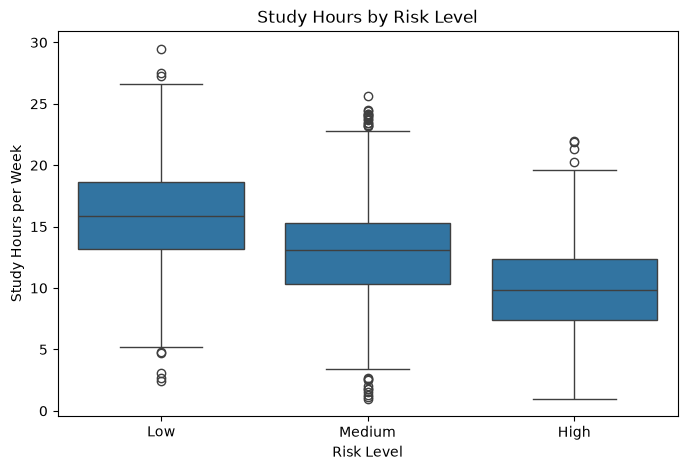

In [30]:
# EDA 6 — Risk vs Study Hours
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="risk_level",
    y="study_hours_week",
    order=["Low", "Medium", "High"]
)

plt.title("Study Hours by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Study Hours per Week")

plt.show()

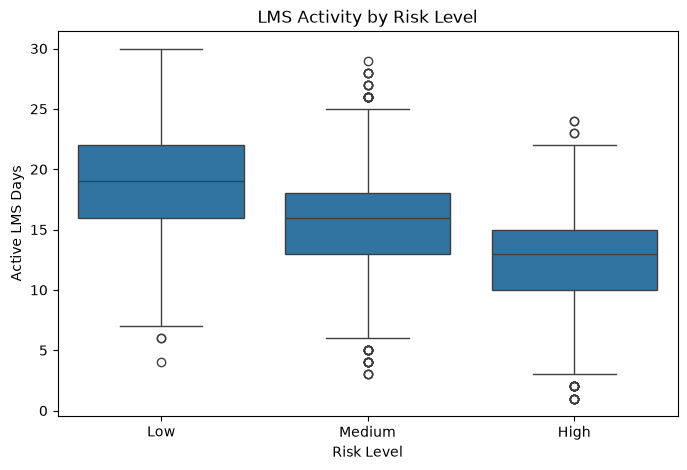

In [31]:
# EDA 7 — Risk vs LMS activity
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="risk_level",
    y="lms_active_days",
    order=["Low", "Medium", "High"]
)

plt.title("LMS Activity by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Active LMS Days")

plt.show()

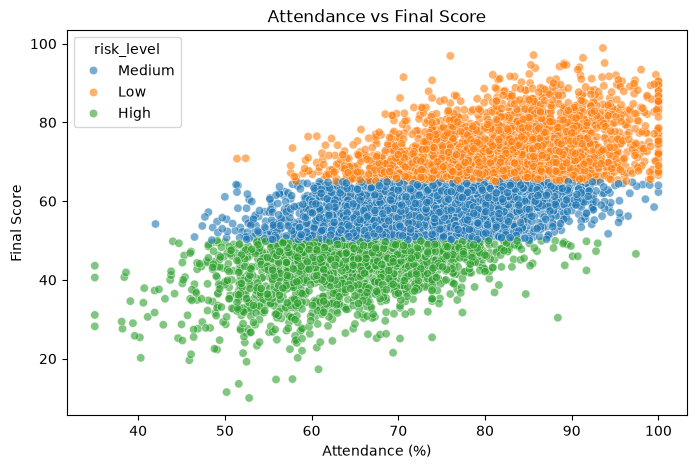

In [32]:
# EDA 9 — Final Score vs Attendance
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="attendance_pct",
    y="final_score",
    hue="risk_level",
    alpha=0.6
)

plt.title("Attendance vs Final Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Final Score")

plt.show()

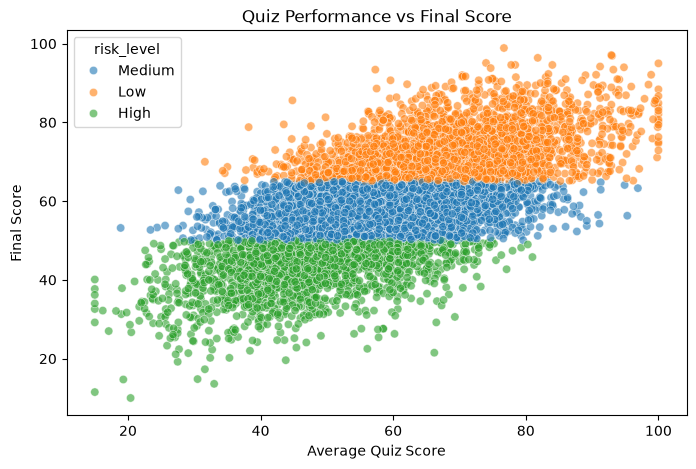

In [33]:
# EDA 10 — Quiz vs Final Score
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="quiz_avg",
    y="final_score",
    hue="risk_level",
    alpha=0.6
)

plt.title("Quiz Performance vs Final Score")
plt.xlabel("Average Quiz Score")
plt.ylabel("Final Score")

plt.show()

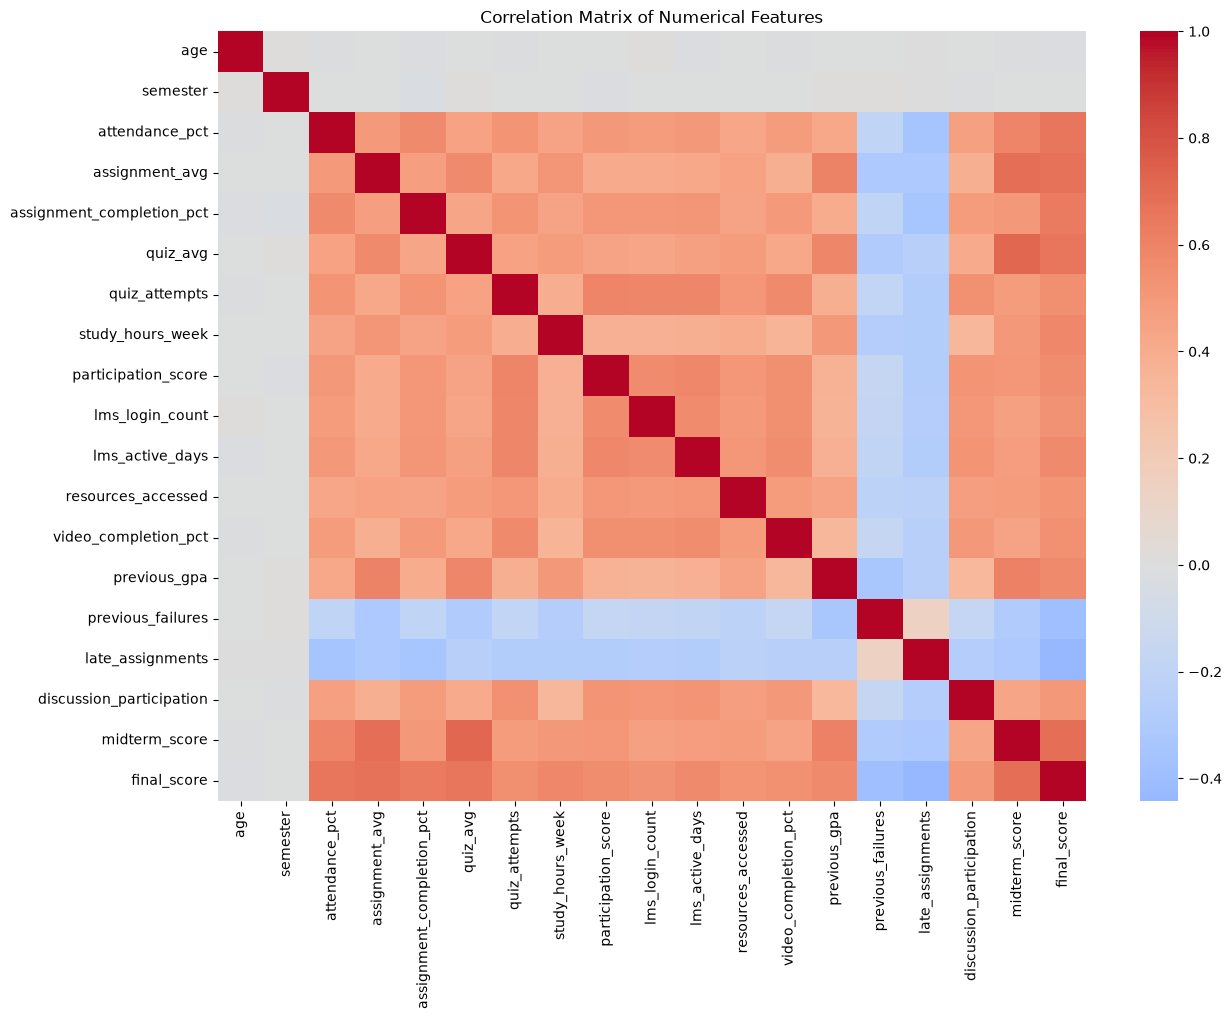

In [ ]:
# EDA 11 — Correlation Heatmap
numeric_df = df.select_dtypes(
    include=["int64", "float64"]
)

correlation = numeric_df.corr()



plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

In [36]:
# DA 14 — Compare important features by risk
risk_summary = df.groupby(
    "risk_level"
)[
    [
        "attendance_pct",
        "assignment_avg",
        "quiz_avg",
        "study_hours_week",
        "participation_score",
        "lms_active_days",
        "previous_gpa",
        "midterm_score"
    ]
].mean().round(2)

risk_summary

,attendance_pct,assignment_avg,quiz_avg,study_hours_week,participation_score,lms_active_days,previous_gpa,midterm_score
risk_level,,,,,,,,
High,64.42,52.18,47.19,9.82,52.54,12.37,5.75,54.17
Low,81.64,73.17,69.56,15.97,71.46,18.86,7.30,73.88
Medium,73.15,62.52,58.29,12.92,62.05,15.64,6.51,64.04
